<a href="https://colab.research.google.com/github/anuhya901-cell/cesppl-internship/blob/main/w2_pandas_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load Dataset and Inspect Data

In [8]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data (1).csv


Print its shape, its columns, and its first ten rows

In [10]:
import pandas as pd

# Load dataset
df = pd.read_csv("data.csv")

# Shape
print("Shape of dataset:")
print(df.shape)

# Columns
print("\nColumns:")
print(df.columns)

# First 10 rows
print("\nFirst 10 rows:")
print(df.head(10))

Shape of dataset:
(3317, 11)

Columns:
Index(['country', 'state', 'city', 'station', 'last_update', 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg'],
      dtype='object')

First 10 rows:
  country           state               city  \
0   India  Andhra_Pradesh              Eluru   
1   India  Andhra_Pradesh             Guntur   
2   India  Andhra_Pradesh             Kadapa   
3   India  Andhra_Pradesh             Kadapa   
4   India  Andhra_Pradesh             Kadapa   
5   India  Andhra_Pradesh      Machilipatnam   
6   India  Andhra_Pradesh  Rajamahendravaram   
7   India  Andhra_Pradesh  Rajamahendravaram   
8   India  Andhra_Pradesh           Tirumala   
9   India  Andhra_Pradesh           Tirumala   

                                          station          last_update  \
0                   District Court, Eluru - APPCB  25-05-2026 14:00:00   
1            Rajendra Nagar North, Guntur - APPCB  25-05-2026 14:00:00   
2   


Find Categorical Columns

In [11]:
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['country', 'state', 'city', 'station', 'last_update', 'pollutant_id'], dtype='object')


Unique Values in Categorical Columns

In [12]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].nunique())


country
1

state
30

city
261

station
496

last_update
1

pollutant_id
7


Mean and Median of Numeric Columns

In [13]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\nMeans:")
print(df[numeric_cols].mean())

print("\nMedians:")
print(df[numeric_cols].median())


Means:
latitude         23.272309
longitude        78.554011
pollutant_min    24.207154
pollutant_max    69.762276
pollutant_avg    41.939187
dtype: float64

Medians:
latitude         23.697936
longitude        77.287209
pollutant_min    13.000000
pollutant_max    40.000000
pollutant_avg    25.000000
dtype: float64


Missing Values Per Column

In [14]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    242
pollutant_max    242
pollutant_avg    242
dtype: int64


 Make at least three matplotlib plots: one bar chart of category counts, one histogram of a numeric column, one scatter or line plot showing a relationship between two columns. Add titles, axis labels, and a legend on each.

GroupBy Aggregation

In [20]:
group_summary = df.groupby("city").agg({
    "pollutant_min": ["mean", "max"]
})

print(group_summary)

              pollutant_min       
                       mean    max
city                              
Agartala          15.166667   41.0
Agra              25.513514  124.0
Ahmedabad         22.127273   70.0
Ahmednagar         5.000000    6.0
Aizawl             2.500000    3.0
...                     ...    ...
Vijayawada        22.384615   55.0
Virar             13.000000   28.0
Visakhapatnam     16.571429   75.0
Vrindavan         16.800000   23.0
Yamuna Nagar      29.000000   90.0

[261 rows x 2 columns]


Matplotlib Plots

In [21]:
import matplotlib.pyplot as plt

Bar Chart

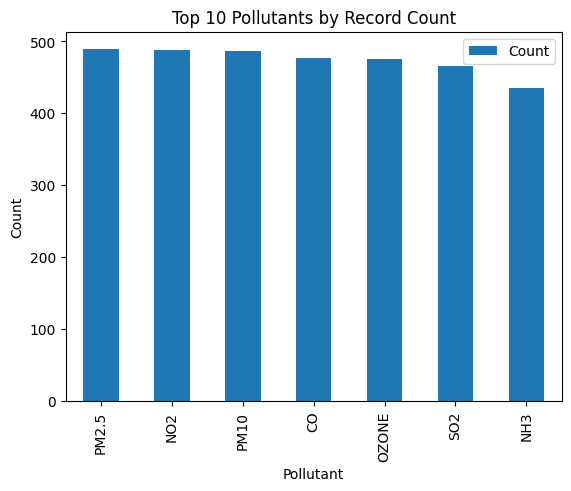

In [22]:
df["pollutant_id"].value_counts().head(10).plot(
    kind="bar",
    legend=True
)

plt.title("Top 10 Pollutants by Record Count")
plt.xlabel("Pollutant")
plt.ylabel("Count")
plt.legend(["Count"])

plt.show()

Histogram

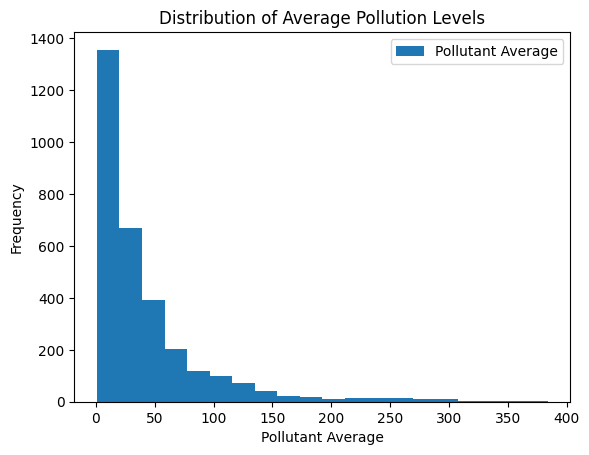

In [23]:
df["pollutant_avg"].plot(
    kind="hist",
    bins=20,
    legend=True
)

plt.title("Distribution of Average Pollution Levels")
plt.xlabel("Pollutant Average")
plt.ylabel("Frequency")
plt.legend(["Pollutant Average"])

plt.show()

Scatter Plot

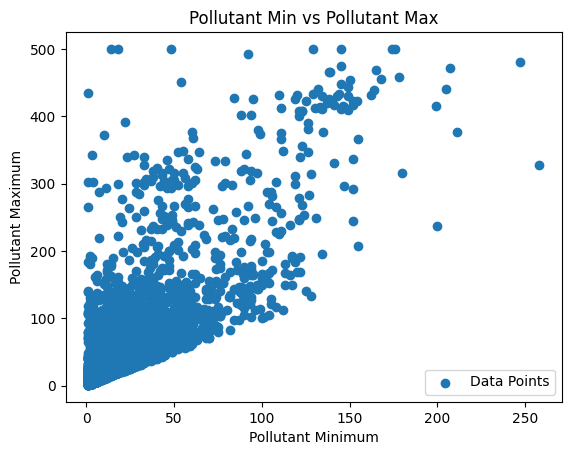

In [24]:
plt.scatter(
    df["pollutant_min"],
    df["pollutant_max"],
    label="Data Points"
)

plt.title("Pollutant Min vs Pollutant Max")
plt.xlabel("Pollutant Minimum")
plt.ylabel("Pollutant Maximum")
plt.legend()

plt.show()

Alternative Scatter Plot

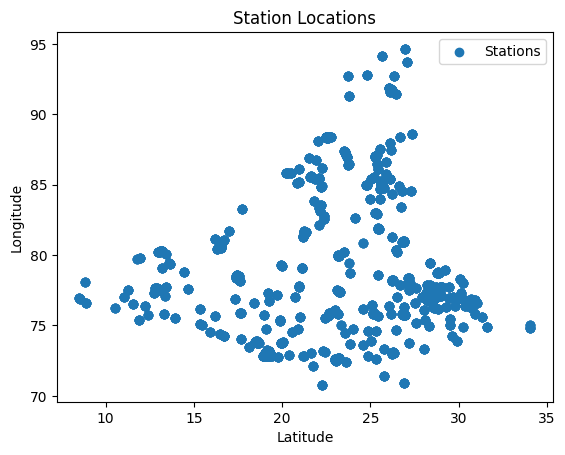

In [25]:
plt.scatter(
    df["latitude"],
    df["longitude"],
    label="Stations"
)

plt.title("Station Locations")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.legend()

plt.show()

# Observations

1. The dataset contains air pollution monitoring data from multiple cities and stations across India, with pollutants such as PM10, PM2.5, NO2, SO2, CO, NH3, and OZONE.

2. Some cities and stations appear multiple times because different pollutants are recorded separately for the same monitoring station and timestamp.

3. The `pollutant_avg` values vary significantly across records, indicating that pollution levels are not uniform across locations and pollutants.

4. Certain pollutants such as PM10 and PM2.5 show relatively high maximum values, which may indicate poor air quality in some areas.

5. The dataset contains both categorical columns (`state`, `city`, `station`, `pollutant_id`) and numeric columns (`latitude`, `longitude`, `pollutant_min`, `pollutant_max`, `pollutant_avg`), making it suitable for grouping, statistical analysis, and visualization.

6. Geographic columns such as latitude and longitude can be used for location-based analysis and mapping of pollution levels.

7. Some stations record multiple pollutant types at the same time, which may create repeated rows for the same station and timestamp combination.

8. Pollution measurements may contain outliers or highly skewed values, which could affect machine learning models and statistical summaries.

9. The dataset may contain missing or inconsistent values in some rows, so preprocessing and data cleaning are important before modeling.

10. Different pollutants have different measurement ranges, so feature scaling may be required if this dataset is used for machine learning.